# Tensor Parallel Training

Tensor parallelism splits individual weight matrices across GPUs instead of replicating the whole model (DDP) or splitting it layer-by-layer (pipeline). Every GPU holds a shard of each weight and they cooperate on computing each matrix multiplication together.

For CIFARNet's three fully connected layers, we split the weights column-wise or row-wise across 2 GPUs. On every forward pass both GPUs process the same input batch each computes a partial result using its weight shard, and a single collective operation at the end of the FC block assembles the full output. The conv layers run identically (replicated) on both GPUs — only the FC layers are tensor-parallel.


## Imports and Constants

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.distributed as dist
from torch.distributed.tensor.parallel import parallelize_module, ColwiseParallel, RowwiseParallel
from torch.distributed._tensor import init_device_mesh, DTensor
from torch.utils.data import DataLoader, RandomSampler
from torchvision import datasets, transforms
import torch.multiprocessing as mp
import matplotlib.pyplot as plt
import random
import time

BATCH_SIZE = 256
EPOCHS = 100 # change back after testing
LEARNING_RATE = 0.1
MOMENTUM = 0.9
WEIGHT_DECAY = 5e-4
MODEL_WEIGHTS_PATH = 'cifar_cnn.pth'
CIFAR_MEAN = (0.49139968, 0.48215827, 0.44653124)
CIFAR_STD  = (0.24703233, 0.24348505, 0.26158768)
CLASSES = ['airplane', 'automobile', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck']

## Model Architecture: CIFARNet

Same model as the other notebooks. We don't change the class definition at all — `parallelize_module` will rewire the FC layers in-place after we create the model, replacing their weight tensors with DTensor shards. The conv layers stay as regular `nn.Module` parameters replicated on both GPUs.

In [2]:
# all networks must extend the nn.Module
class CIFARNet(nn.Module):
    def __init__(self):
        super().__init__()
        # networks must define a constructor to create all of the layers that the network will use

        # our network has 4 convolution layers with 3 mlp layers
        # Our original images have a size of 3x32x32 (3 for rgb then 32x32 image sizes)
        # so we can view each image as having 3 channels i.e 3 seperate images
        # and we convolute over that with 64 different kernels to create 64 new images
        # the convulution matrix will look over all input channels at once so it will take all rgb into account in one go
        # we then create several more convolution layers increasing the number of channels each time
        # kernel_size 3 means we convolute our images with a 3x3 matrix, padding 1 means we make our image 1 pixel bigger on each side
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.conv4 = nn.Conv2d(256, 512, kernel_size=3, padding=1)

        # max pool is an operation that just takes the max from a 2x2 grid
        # it is used to reduce the size of images for faster processing without missing key details
        self.pool = nn.MaxPool2d(2, 2)

        # Batch norm normalizes an entire input to the layer of a neural network to keep all activations reasonable
        # we batch normalize for each convolution layer
        self.bn1 = nn.BatchNorm2d(64)
        self.bn2 = nn.BatchNorm2d(128)
        self.bn3 = nn.BatchNorm2d(256)
        self.bn4 = nn.BatchNorm2d(512)

        # dropout means to randomly turn off half the nodes to prevent overfitting
        # this is only used during the training phase and not during testing
        self.dropout = nn.Dropout(p=0.5)

        # the final step in our network is the full connected layers of which we have 3 of
        # We have as input to the first linear layer 512 * 8 * 8 nodes since the last layer of convolution
        # has dimention (B, 512, 8, 8) so that allows one node for each pixel/channel
        # the last layer has 10 nodes since there are 10 different classes we want to identify
        self.fc1 = nn.Linear(512 * 8 * 8, 512)
        self.fc2 = nn.Linear(512, 256)
        self.fc3 = nn.Linear(256, 10)

    def forward(self, x):
        # the forward method defines how data is passed through the layers we created in init

        # for our convolution layers we follow the same basic pattern
        # convlute the input tensor (the raw image)
        # max pool it to reduce the size
        # batch normalize
        # relu (activation function) max(0, x)
        # starting data size is (B, 3, 32, 32)
        x = self.conv1(x) # (B, 64, 32, 32) is the output where B is batch size
        x = self.pool(x)  # (B, 64, 16, 16) output from pool, notice the size of our data is cut in 1/4
        x = self.bn1(x)   # batch normalization doesn't change the size of the data just normalizes the activations
        x = F.relu(x)     # (B, 64, 16, 16) doesn't change the size of the data

        x = self.conv2(x) # (B, 128, 16, 16)
        x = self.pool(x)  # (B, 128, 8, 8) notice size of data cut in 1/4 again
        x = self.bn2(x)
        x = F.relu(x)     # (B, 128, 8, 8)

        x = self.conv3(x) # (B, 256, 8, 8)
        # we don't pool here since our image is already now pretty small
        x = self.bn3(x)
        x = F.relu(x)

        x = self.conv4(x) # (B, 512, 8, 8)
        x = self.bn4(x)
        x = F.relu(x)

        # final shape of data after all convolutions (B, 512, 8, 8)

        # to prepare to put our tensore in the neural network we must flatten it
        # the 1 means to start flattening with the first dimension so only the 512, 8, 8 are flattened
        # this is critical because without that we would flatten all batches into one giant tensore which would be useless
        x = torch.flatten(x, 1) # (B, 512 * 8 * 8) = (B, 32768) output of flatten

        # now we can pass through our flattened tensors into the fully connected layer and another relu activation
        # fc1 is ColwiseParallel: each gpu holds half the output features, producing (B, 256) sharded
        x = self.fc1(x) # (B, 512) total, each gpu computes (B, 256) of this
        x = F.relu(x)

        # randomly turn some of the values to 0 to prevent overfitting
        x = self.dropout(x)
        # fc2 is RowwiseParallel: each gpu holds half the input features, all-reduce gives full (B, 256) on both gpus
        x = self.fc2(x) # (B, 256) replicated on both gpus after all-reduce
        x = F.relu(x)

        x = self.dropout(x)
        # pass through last fc layer but do not relu because we will softmax later to get probabilities for each class
        # fc3 runs replicated, only 10 output classes so the benefit of splitting it is minimal
        x = self.fc3(x) # (B, 10) final size of output

        return x

## Data Loading for Tensor Parallelism

Unlike DDP where each GPU sees a different subset of the data, tensor parallelism requires every GPU to process the same batch on every step — otherwise the partial matrix products on each GPU would correspond to different inputs and the result would be garbage.

We use a `RandomSampler` with a fixed seed on both ranks so they iterate through the dataset in exactly the same order. This is the same trick used in the pipeline parallel notebook to keep rank 0 and rank 1 in lockstep.

In [3]:
def get_cifar_data_transforms():
    # create a set of augmentations we want to do to our training and data set.
    # for the training set we randomly flip the image to better generalize
    # and also randomly crop out a small portion of it
    # then we normalize the rgb values to be ~N(0,1)
    transform_train = transforms.Compose([
        transforms.RandomHorizontalFlip(),
        transforms.RandomCrop(32, padding=4),
        transforms.ToTensor(),
        transforms.Normalize(mean=CIFAR_MEAN, std=CIFAR_STD),
    ])
    # We do not augment the data if testing our classifier because we do not want to hinder the model in any way
    transform_test = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=CIFAR_MEAN, std=CIFAR_STD),
    ])
    return transform_train, transform_test


def get_cifar_data_sets(transform_train, transform_test):
    train_set = datasets.CIFAR10(
        root='./data', train=True, download=True, transform=transform_train,
    )
    test_set = datasets.CIFAR10(
        root='./data', train=False, download=True, transform=transform_test,
    )
    return train_set, test_set


def cifar10_loaders_tensor_parallel(batch_size=BATCH_SIZE, shuffle_seed=42):
    transform_train, transform_test = get_cifar_data_transforms()
    train_set, test_set = get_cifar_data_sets(transform_train, transform_test)

    # Create a generator with a fixed seed so every rank iterates in the same order
    # Without this, each process would shuffle independently and see different batches
    generator = torch.Generator()
    generator.manual_seed(shuffle_seed)

    train_loader = DataLoader(
        train_set,
        batch_size=batch_size,
        shuffle=False,
        sampler=RandomSampler(train_set, generator=generator),
        pin_memory=True,
        num_workers=4,
        drop_last=True,
    )
    test_loader = DataLoader(
        test_set,
        batch_size=batch_size,
        shuffle=False,
        pin_memory=True,
        num_workers=4,
        drop_last=True,
    )
    return train_loader, test_loader

## Device Mesh and Tensor Parallel Plan

A **DeviceMesh** is PyTorch's abstraction for a group of devices that will cooperate on parallelism. For 2-GPU tensor parallelism, it's a 1D mesh of size 2.

`parallelize_module` rewires specific layers to use DTensor shards. We apply two complementary styles to fc1 and fc2, forming a Col→Row pair — the standard building block for tensor-parallel MLP blocks:

- ColwiseParallel on fc1 — splits the weight along the output dimension. Each GPU holds half the output features. Input is replicated, output is sharded.
- `RowwiseParallel` on fc2 — splits the weight along the input dimension. Each GPU holds half the input features, which matches the sharded output from fc1. A single all-reduce at the end reconstructs the full output on both GPUs.

fc3 stays replicated on both GPUs — it only has 10 outputs so splitting it gives minimal benefit, and it avoids an extra communication.

## Tensor Parallel Training Worker

Each process builds a full `CIFARNet`, moves it to its GPU, then calls `parallelize_module` to shard the FC layers in-place. After that the training loop looks almost identical to single-GPU training — PyTorch handles all the DTensor communication transparently during `forward()` and `backward()`.

Because both GPUs always see the same batch and produce identical outputs after the final all-reduce, we only need one optimizer and one set of gradients per GPU (for its local weight shards). There's no need to manually sync gradients like DDP does.

In [4]:
def tensor_parallel_worker(rank, world_size):
    torch.cuda.set_device(rank)
    device = torch.device(f'cuda:{rank}')

    # initialize NCCL so GPUs can communicate during the all-reduce inside fc2
    dist.init_process_group(
        backend='nccl',
        init_method='tcp://127.0.0.1:12357',
        rank=rank,
        world_size=world_size,
    )

    if rank == 0:
        print(f'Tensor Parallelism on {world_size} GPUs')

    # both ranks load the same data in the same order using the fixed-seed sampler
    train_loader, test_loader = cifar10_loaders_tensor_parallel(BATCH_SIZE)

    # Build the full model on this GPU, parallelize_module will shard fc1 and fc2 in-place
    model = CIFARNet().to(device)

    # A DeviceMesh organizes gpus into an n dimensional grid
    # mesh_shape (world_size,) creates a 1D mesh, all GPUs in one tensor-parallel group
    # you can use multiple dimension to add data and tensor parallelism
    tensor_parallel_mesh = init_device_mesh('cuda', (world_size,))

    # Apply tensor parallelism to fc1 and fc2 as a Col->Row pair
    parallelize_module(
        model,
        tensor_parallel_mesh,
        {
            'fc1': ColwiseParallel(),
            'fc2': RowwiseParallel(),
        }
    )

    # Loss and optimizer,one optimizer per rank, each only updates its local weight shards
    # no gradient synchronization is needed between gpus because each gpu owns different parameters
    # foreach=False is required because the model has a mix of regular tensors (conv layers, fc3)
    # and DTensors (fc1, fc2 shards), the default foreach batch update path can't handle both types
    loss_function = nn.CrossEntropyLoss()
    optimizer = optim.SGD(
        model.parameters(),
        lr=LEARNING_RATE,
        momentum=MOMENTUM,
        weight_decay=WEIGHT_DECAY,
        foreach=False,
    )
    # automatically changes the learning rate to learn faster at the beginning and then more precise later
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

    for epoch in range(EPOCHS):
        if rank == 0:
            print(f'\nEpoch {epoch + 1}/{EPOCHS}')
            start_time = time.time()

        # TRAIN LOOP
        model.train()
        train_correct = 0
        train_total = 0

        for images, labels in train_loader:
            # both gpus receive identical images and labels because of the fixed-seed sampler
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()

            # forward pass: conv layers run fully on each gpu, fc1/fc2 use dtensor sharding
            # the all-reduce inside fc2 gives both gpus the same (B, 256) output going into fc3
            outputs = model(images)

            # loss measures how far our actual probabilities are from the one hot encoded truth labels
            loss = loss_function(outputs, labels)
            # backward propagates gradients through dtensor ops automatically
            # each gpu accumulates gradients only for the weight shards it owns
            loss.backward()
            optimizer.step()

            _, predicted = torch.max(outputs, 1)
            train_correct += (predicted == labels).sum().item()
            train_total += labels.size(0)

        scheduler.step()

        train_accuracy = 100.0 * train_correct / train_total

        # TEST LOOP
        # eval turns off things that help with training but hinder performance like dropout
        model.eval()
        correct, total = 0, 0

        # disables gradient calculation so our model can't learn from the testing data and cheat
        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, predicted = torch.max(outputs, 1)
                correct += (predicted == labels).sum().item()
                total += labels.size(0)

        accuracy = 100.0 * correct / total

        if rank == 0:
            print(f'  Training Accuracy: {train_accuracy:.2f}%')
            print(f'  Test Accuracy:     {accuracy:.2f}%')
            print(f'  Epoch time:        {(time.time() - start_time):.2f}s')

    # state_dict() includes both parameters and buffers (e.g. BatchNorm running_mean/running_var)
    # named_parameters() would miss the buffers and produce an incomplete checkpoint
    # full_tensor() is a collective so all ranks must call it before rank 0 writes the file
    clean_state = {}
    for name, tensor in model.state_dict().items():
        if isinstance(tensor, DTensor):
            # triggers an all-gather across both gpus to reconstruct the full weight matrix
            clean_state[name] = tensor.full_tensor().cpu()
        else:
            clean_state[name] = tensor.cpu()

    # only rank 0 writes the file — both ranks have identical clean_state at this point
    if rank == 0:
        torch.save(clean_state, MODEL_WEIGHTS_PATH)
        print(f'\nSaved model weights to {MODEL_WEIGHTS_PATH}')

    dist.destroy_process_group()

## Launch Tensor Parallel Training

In [5]:
assert torch.cuda.device_count() >= 2, (
    'This notebook requires 2 GPUs. '
    'Go to Settings -> Accelerator -> GPU T4 x2 and re-run.'
)

# clean up any stale process groups from a previous run
if dist.is_initialized():
    dist.destroy_process_group()

world_size = torch.cuda.device_count()
print(f'Found {world_size} GPU(s)')

with mp.Manager() as manager:
    mp.start_processes(tensor_parallel_worker, args=(world_size,), nprocs=world_size, join=True, start_method='fork')

Found 2 GPU(s)
Tensor Parallelism on 2 GPUs

Epoch 1/100
  Training Accuracy: 22.37%
  Test Accuracy:     25.90%
  Epoch time:        22.80s

Epoch 2/100
  Training Accuracy: 24.85%
  Test Accuracy:     29.44%
  Epoch time:        21.82s

Epoch 3/100
  Training Accuracy: 29.13%
  Test Accuracy:     36.85%
  Epoch time:        21.70s

Epoch 4/100
  Training Accuracy: 35.52%
  Test Accuracy:     40.89%
  Epoch time:        20.42s

Epoch 5/100
  Training Accuracy: 42.31%
  Test Accuracy:     45.37%
  Epoch time:        20.34s

Epoch 6/100
  Training Accuracy: 50.30%
  Test Accuracy:     54.17%
  Epoch time:        20.70s

Epoch 7/100
  Training Accuracy: 55.50%
  Test Accuracy:     59.91%
  Epoch time:        21.07s

Epoch 8/100
  Training Accuracy: 62.14%
  Test Accuracy:     63.71%
  Epoch time:        21.90s

Epoch 9/100
  Training Accuracy: 66.78%
  Test Accuracy:     71.85%
  Epoch time:        22.52s

Epoch 10/100
  Training Accuracy: 69.98%
  Test Accuracy:     71.69%
  Epoch time:

## Inference

After training, `cifar_cnn.pth` holds the fully reassembled weights (rank 0 gathered all shards before saving). We load them into a plain `CIFARNet` on one GPU — no tensor parallelism needed for inference on a single image.

------- Inference Result -------
Random Test Index: 1001
Predicted class:   airplane
True label:        airplane
--------------------------------


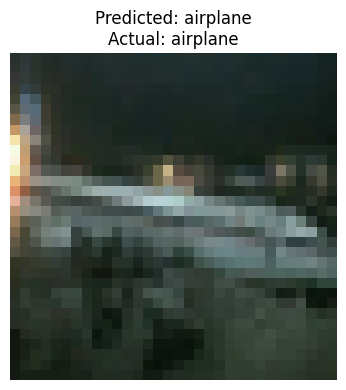

In [16]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

# load the trained model and put it on the device we are using
# the saved weights are full tensors (gathered from shards during training) so this is straightforward
model_inf = CIFARNet().to(device)
model_inf.load_state_dict(torch.load(MODEL_WEIGHTS_PATH, map_location=device))
model_inf.eval()

# get our test data set
transform_train, transform_test = get_cifar_data_transforms()
_, test_set = get_cifar_data_sets(transform_train, transform_test)

# pick a random test image
idx = random.randint(0, len(test_set) - 1)
image, label = test_set[idx]

# save unnormalized copy for display, reverse the normalization so colors look right
unnorm = image.clone()
for t, m, s in zip(unnorm, CIFAR_MEAN, CIFAR_STD):
    t.mul_(s).add_(m)
np_img = unnorm.permute(1, 2, 0).numpy()

# run inference
image_batch = image.unsqueeze(0).to(device)
with torch.no_grad():
    output = model_inf(image_batch)
    predicted_idx = output.argmax(dim=1).item()

predicted_class = CLASSES[predicted_idx]
true_class = CLASSES[label]

print('------- Inference Result -------')
print(f'Random Test Index: {idx}')
print(f'Predicted class:   {predicted_class}')
print(f'True label:        {true_class}')
print('--------------------------------')

plt.figure(figsize=(4, 4))
plt.imshow(np_img)
plt.title(f'Predicted: {predicted_class}\nActual: {true_class}', fontsize=12)
plt.axis('off')
plt.tight_layout()
plt.show()